In [107]:
import pandas as pd
import cupy as cp
import cudf
import cuml
import torch
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns
from cuml import KMeans
from cuml.cluster import KMeans
from sklearn.decomposition import PCA

In [108]:
df_pandas = pd.read_csv('household_power_consumption_not_null.csv', parse_dates=[['Date', 'Time']],
                       date_format = {'Date': '%d/%m/%Y', 
                                      'Time': '%H:%M:%S'},
                       dayfirst = True)
df_pandas

/tmp/ipykernel_38803/4030125953.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_pandas = pd.read_csv('household_power_consumption_not_null.csv', parse_dates=[['Date', 'Time']],


,Date_Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2049275,2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2049276,2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2049277,2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2049278,2010-11-26 21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [109]:
df_cudf_1 = cudf.DataFrame(df_pandas)
df_cudf_1

,Date_Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2049275,2010-11-26 20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2049276,2010-11-26 20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2049277,2010-11-26 21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2049278,2010-11-26 21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [110]:
df_cudf_1 = df_cudf_1.astype(float)
df_cudf_1

,Date_Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,1.166290e+18,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,1.166290e+18,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,1.166290e+18,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,1.166290e+18,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,1.166290e+18,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...
2049275,1.290805e+18,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2049276,1.290805e+18,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2049277,1.290805e+18,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2049278,1.290805e+18,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [116]:
class Clustering(object):

    def __init__(self, dataset, plotting_type: str, n_clusters: int, max_iter: int, verbose: int, random_state: int, 
                 init: str, n_init: str, oversampling_factor: float, max_samples_per_batch: int, output_type: str,
                plotting_x: str, plotting_y: str,):
        self.dataset = dataset.copy().reset_index(drop = True)
        self.plotting_type = plotting_type
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.verbose = verbose
        self.random_state = random_state
        self.init = init
        self.n_init = n_init
        self.oversampling_factor = oversampling_factor
        self.max_samples_per_batch = max_samples_per_batch
        self.output_type = output_type
        self.plotting_x = plotting_x
        self.plotting_y = plotting_y
        

    def KMeans(self):
        global kmeans_global
        global labels_global
        global cluster_centers_global
        
        kmeans_float = cuml.cluster.KMeans(n_clusters=self.n_clusters, max_iter=self.max_iter, tol=0.0001, verbose=self.verbose, 
                                           random_state=self.random_state, init=self.init, n_init=self.n_init, 
                                           oversampling_factor=self.oversampling_factor,
                                           max_samples_per_batch=self.max_samples_per_batch, output_type=self.output_type)
        kmeans = kmeans_float.fit(self.dataset)
        kmeans_global = kmeans

        labels = kmeans_float.labels_
        labels_global = cudf.DataFrame(labels, columns=['Labels'])

        cluster_centers = kmeans_float.cluster_centers_
        cluster_centers_global = cluster_centers

    def labels_concat(self):
        global df_concat_global
        global df_concat_pandas_global

        df_concat = cudf.concat([df_cudf_1, labels_global], axis=1)
        df_concat_global = df_concat

        df_concat_pandas = df_concat.to_pandas()
        df_concat_pandas_global = df_concat_pandas

    def plotting(self):

        if self.plotting_type == 'matplotlib':
            x=df_concat_pandas_global[self.plotting_x]
            y=df_concat_pandas_global[self.plotting_y]
            Cluster = df_concat_pandas_global['Labels']

            fig = plt.figure()
            ax = fig.add_subplot(111)
            scatter = ax.scatter(x,y,c=Cluster,s=50)
            plt.colorbar(scatter)
            plt.xlabel(self.plotting_x)
            plt.ylabel(self.plotting_y)

            fig.show()

            # Reduce to 2 dimensions
            pca = PCA(n_components=2)
            X_pca = pca.fit_transform(df_concat_pandas_global)

            # Plot the reduced data
            plt.figure(figsize=(8, 6))
            scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_concat_pandas_global['Labels'], cmap='coolwarm', s=50)

            plt.title("Clustering Labels visualized via PCA")
            plt.show()

        elif self.plotting_type == 'seaborn':
            
            sns.scatterplot(data=df_concat_pandas_global, x=self.plotting_x, y=self.plotting_y, hue='Labels', palette='Set1')
            plt.show()
        
        
    def main(self):
        st = time.time()
        self.KMeans()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        st = time.time()
        self.labels_concat()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        st = time.time()
        self.plotting()
        et = time.time()
        elapsed_time = et - st
        print('Execution time:', elapsed_time, 'seconds')
        

In [117]:
clust_matplotlib = Clustering(df_cudf_1, 'matplotlib', 20, 300, 0, 10, 'scalable-k-means++', 'auto', 
                   2.0, 32768, None, 'Global_active_power', 'Voltage')

Execution time: 6.383148670196533 seconds
Execution time: 0.08154010772705078 seconds


/tmp/ipykernel_38803/2110073947.py:63: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


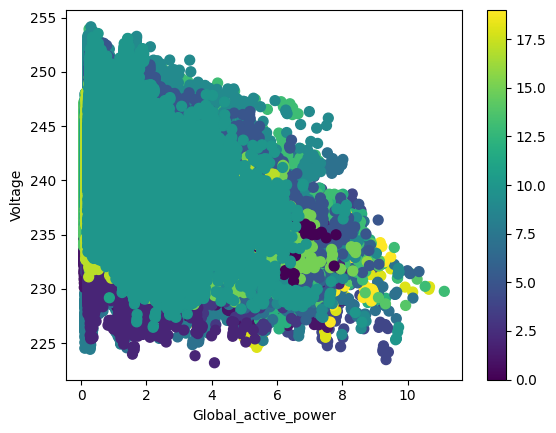

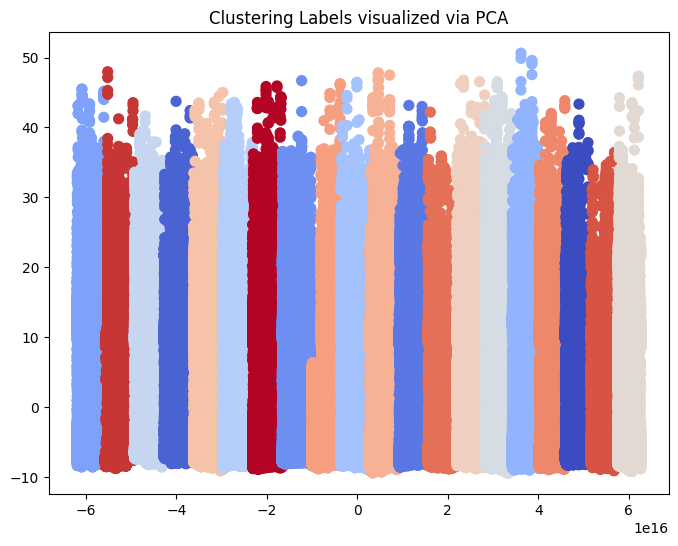

Execution time: 38.914740562438965 seconds


In [118]:
clust_matplotlib.main()

In [119]:
clust_seaborn = Clustering(df_cudf_1, 'seaborn', 20, 300, 0, 10, 'scalable-k-means++', 'auto', 
                   2.0, 32768, None, 'Global_active_power', 'Voltage')

Execution time: 6.383092880249023 seconds
Execution time: 0.11168980598449707 seconds


/home/xy/Desktop/ml/rapid-cudf-minimal/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


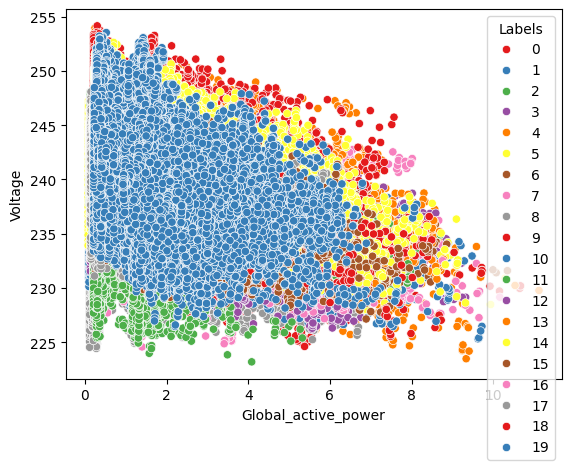

Execution time: 37.265480756759644 seconds


In [120]:
clust_seaborn.main()